# 02 - Macrosomia Risk Score Model Training (LightGBM Regression)

## Project: Agentic AI for Pregnancy Monitoring
### Task: Predict **Macrosomia Risk Score** (0–1) using metabolic + lifestyle patient data  
✅ Model Type: **Regression (LightGBM)**  
✅ Output: `macrosomia_risk_score`  
✅ Tiering: Rule-based thresholds (Low/Medium/High)

---

### Key Notes
- We use **patient-wise split** (`patient_id`) to prevent data leakage.
- We use **feature engineering** (Glucose Spike, Above Target Flags).
- We use **missing indicators** for periodic/manual fields (weight, HbA1c).
- We encode diet text (`food_log_text`) into stable categories.
- Target column: `macrosomia_risk_score_label`


In [1]:
# If LightGBM is not installed, uncomment below:
# !pip install lightgbm

import pandas as pd
import numpy as np

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder
import joblib
import json
import os

import lightgbm as lgb

np.random.seed(42)


## 1) Load Dataset

We load the final dataset and verify:
- shape
- missing values
- target distribution


In [2]:
DATA_PATH = "pregnancy_dataset_v2.csv"  # change if needed

df = pd.read_csv(DATA_PATH)

print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (5000, 25)


,patient_id,timestamp,gestational_age_weeks,systolic_bp,diastolic_bp,severe_headache,vision_changes,upper_abdominal_pain,swelling_face_hands,proteinuria_dipstick,...,weight_kg,maternal_age,pre_pregnancy_bmi,gdm_diagnosed,hba1c,preeclampsia_risk_tier,macrosomia_risk_tier,preeclampsia_risk_score_label,macrosomia_risk_score_label,timestamp_parsed
0,P0079,2025-06-05 15:49:32,35,104,91,0,0,0,1,NaN,...,91.2,25,33.6,1,5.7,medium,high,0.53,1.00,2025-06-05 15:49:32
1,P0197,2025-08-30 20:50:59,23,150,98,0,1,0,0,3.0,...,NaN,23,43.5,0,NaN,high,low,0.80,0.21,2025-08-30 20:50:59
2,P0217,2025-11-25 18:19:39,36,180,108,1,0,1,0,NaN,...,116.4,19,39.3,0,NaN,high,medium,0.92,0.64,2025-11-25 18:19:39
3,P0279,2025-07-23 08:01:26,37,109,76,0,0,1,0,NaN,...,117.8,31,43.1,0,NaN,low,high,0.22,0.79,2025-07-23 08:01:26
4,P0457,2025-11-24 13:03:32,33,95,81,0,0,0,0,0.0,...,NaN,41,39.7,1,5.3,low,medium,0.10,0.68,2025-11-24 13:03:32


In [3]:
print("\nMissing % (Top 10):")
display((df.isna().mean() * 100).sort_values(ascending=False).head(10))

print("\nTarget stats:")
display(df["macrosomia_risk_score_label"].describe())



Missing % (Top 10):


hba1c                    82.58
proteinuria_dipstick     59.66
weight_kg                52.20
timestamp                 0.00
diastolic_bp              0.00
severe_headache           0.00
gestational_age_weeks     0.00
systolic_bp               0.00
patient_id                0.00
swelling_face_hands       0.00
dtype: float64


Target stats:


count    5000.000000
mean        0.462390
std         0.304248
min         0.080000
25%         0.210000
50%         0.430000
75%         0.700000
max         1.000000
Name: macrosomia_risk_score_label, dtype: float64

## 2) Define Target and Drop Columns

### Target (y)
- `macrosomia_risk_score_label`

### Exclusions
We remove:
- tiers (derived output)
- preeclampsia targets (not needed here)
- timestamp (not used directly)


In [4]:
TARGET = "macrosomia_risk_score_label"
GROUP_COL = "patient_id"

DROP_COLS = [
    "timestamp",

    # Targets / tiers not used
    "preeclampsia_risk_tier",
    "macrosomia_risk_tier",
    "preeclampsia_risk_score_label"
]


## 3) Feature Engineering (Macrosomia-focused)

We add clinically meaningful engineered features:

✅ Glucose spike size  
- `glucose_spike = postprandial_1hr_glucose - fasting_glucose`

✅ Target flags (based on ACOG targets)
- fasting target <95 mg/dL
- 1-hour post meal target <140 mg/dL

Features:
- `fasting_above_target_flag` (fasting >= 95)
- `postmeal_above_target_flag` (1-hr >= 140)
- `high_spike_flag` (1-hr >= 180)

✅ Missingness indicators
- `weight_missing`
- `hba1c_missing`

✅ Diet category encoding
- `food_log_text` -> `meal_category`


In [5]:
def extract_meal_category(text: str) -> str:
    """
    Convert food_log_text into a few stable diet categories.
    This encoding is retraining-safe and deployment-friendly.
    """
    if pd.isna(text):
        return "unknown"

    t = str(text).lower()

    if any(k in t for k in ["bagel", "pasta", "white rice", "potatoes", "bread"]):
        return "high_carb"

    if any(k in t for k in ["juice", "soda", "milkshake"]):
        return "sugary"

    if any(k in t for k in ["egg", "eggs", "paneer", "fish", "yogurt", "chicken"]):
        return "protein"

    if any(k in t for k in ["cookies", "chips", "instant noodles"]):
        return "processed_snack"

    if any(k in t for k in ["chapati", "dal", "vegetables", "salad", "idli", "sambar", "brown rice"]):
        return "balanced"

    return "other"


def add_derived_features(data: pd.DataFrame) -> pd.DataFrame:
    df_ = data.copy()

    # Glucose spike (post meal rise)
    df_["glucose_spike"] = df_["postprandial_1hr_glucose"] - df_["fasting_glucose"]

    # ACOG target-based flags
    df_["fasting_above_target_flag"] = (df_["fasting_glucose"] >= 95).astype(int)
    df_["postmeal_above_target_flag"] = (df_["postprandial_1hr_glucose"] >= 140).astype(int)
    df_["high_spike_flag"] = (df_["postprandial_1hr_glucose"] >= 180).astype(int)

    # Missing indicators (important because these are periodic/manual)
    df_["weight_missing"] = df_["weight_kg"].isna().astype(int)
    df_["hba1c_missing"] = df_["hba1c"].isna().astype(int)

    # Diet category
    df_["meal_category"] = df_["food_log_text"].apply(extract_meal_category)

    return df_


In [6]:
df_fe = add_derived_features(df)

print("Shape after feature engineering:", df_fe.shape)

df_fe[[
    "fasting_glucose",
    "postprandial_1hr_glucose",
    "glucose_spike",
    "fasting_above_target_flag",
    "postmeal_above_target_flag",
    "high_spike_flag",
    "food_log_text",
    "meal_category"
]].head()


Shape after feature engineering: (5000, 32)


,fasting_glucose,postprandial_1hr_glucose,glucose_spike,fasting_above_target_flag,postmeal_above_target_flag,high_spike_flag,food_log_text,meal_category
0,96.0,170.0,74.0,1,1,0,instant noodles,processed_snack
1,90.0,112.0,22.0,0,0,0,chapati + dal + vegetables,balanced
2,83.0,171.0,88.0,0,1,0,white rice + potatoes,high_carb
3,88.0,191.0,103.0,0,1,1,pasta + bread,high_carb
4,93.0,170.0,77.0,0,1,0,milkshake,sugary


## 4) Encode Diet Category (`meal_category`)

We encode meal category into numeric format using LabelEncoder.
This is stable and deployment-friendly.


In [7]:
le_meal = LabelEncoder()
df_fe["meal_category_encoded"] = le_meal.fit_transform(df_fe["meal_category"])

print("Meal categories mapping:")
for cls, enc in zip(le_meal.classes_, range(len(le_meal.classes_))):
    print(f"{cls} -> {enc}")


Meal categories mapping:
balanced -> 0
high_carb -> 1
processed_snack -> 2
protein -> 3
sugary -> 4


## 5) Restrict Features for Macrosomia Model ✅

Even though the dataset contains both PE + macrosomia fields,
the macrosomia model must use only macrosomia-focused inputs:

✅ glucose + BMI + weight + HbA1c + lifestyle + diet category + engineered features  
❌ no BP symptoms, no proteinuria, no PE features


In [8]:
MAC_FEATURES = [
    # Common context
    "gestational_age_weeks",
    "maternal_age",

    # Core glucose
    "fasting_glucose",
    "postprandial_1hr_glucose",

    # Diabetes/lab context
    "gdm_diagnosed",
    "hba1c",

    # Anthropometrics
    "pre_pregnancy_bmi",
    "weight_kg",

    # Lifestyle
    "post_meal_walk_minutes",
    "sleep_hours",

    # Encoded diet
    "meal_category_encoded",

    # Engineered glucose features
    "glucose_spike",
    "fasting_above_target_flag",
    "postmeal_above_target_flag",
    "high_spike_flag",

    # Missingness features
    "weight_missing",
    "hba1c_missing"
]

X_cols = [c for c in MAC_FEATURES if c in df_fe.columns]

print("✅ Final Macrosomia feature count:", len(X_cols))
print(X_cols)

X = df_fe[X_cols]
y = df_fe[TARGET]
groups = df_fe[GROUP_COL]

print("X shape:", X.shape)
print("y shape:", y.shape)


✅ Final Macrosomia feature count: 17
['gestational_age_weeks', 'maternal_age', 'fasting_glucose', 'postprandial_1hr_glucose', 'gdm_diagnosed', 'hba1c', 'pre_pregnancy_bmi', 'weight_kg', 'post_meal_walk_minutes', 'sleep_hours', 'meal_category_encoded', 'glucose_spike', 'fasting_above_target_flag', 'postmeal_above_target_flag', 'high_spike_flag', 'weight_missing', 'hba1c_missing']
X shape: (5000, 17)
y shape: (5000,)


## 6) Patient-wise Train/Test Split (Group Split)

We split using `patient_id` so that a patient never appears in both train and test.
This ensures performance is valid and not inflated.


In [9]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

print("\nUnique train patients:", groups.iloc[train_idx].nunique())
print("Unique test patients :", groups.iloc[test_idx].nunique())


Train shape: (4034, 17)
Test shape : (966, 17)

Unique train patients: 398
Unique test patients : 100


## 7) Train LightGBM Regressor (with Early Stopping)

We train a regression model to predict macrosomia risk score (0–1).
Early stopping helps prevent overfitting.


In [10]:
model = lgb.LGBMRegressor(
    objective="regression",
    n_estimators=3000,
    learning_rate=0.02,
    num_leaves=63,
    max_depth=8,
    min_child_samples=60,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.2,
    reg_lambda=0.5,
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric="l2",
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=True)]
)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000924 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 942
[LightGBM] [Info] Number of data points in the train set: 4034, number of used features: 17
[LightGBM] [Info] Start training from score 0.456648
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM]

LGBMRegressor(colsample_bytree=0.8, learning_rate=0.02, max_depth=8,
              min_child_samples=60, n_estimators=3000, num_leaves=63,
              objective='regression', random_state=42, reg_alpha=0.2,
              reg_lambda=0.5, subsample=0.8)

## 8) Model Evaluation

We evaluate using:
✅ R²  
✅ MAE  
✅ RMSE  

Goal: valid R² ≥ 0.90 (ideally ≥ 0.95)


In [11]:
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

# RMSE fix (no FutureWarning)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("✅ Macrosomia Risk Score Model Metrics")
print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")


✅ Macrosomia Risk Score Model Metrics
R²   : 0.9984
MAE  : 0.0062
RMSE : 0.0128


## 9) Sample Predictions (Sanity Check)


In [12]:
preview = pd.DataFrame({
    "actual_score": y_test.values[:15],
    "predicted_score": y_pred[:15]
})
preview


,actual_score,predicted_score
0,1.00,0.999026
1,0.29,0.290687
2,0.56,0.557961
3,0.29,0.289487
4,0.13,0.130658
5,0.43,0.442472
6,0.21,0.208725
7,1.00,1.003056
8,0.56,0.561716
9,1.00,0.998161


## 10) Risk Tier Derivation (Rule-Based)

We do NOT train a classifier model.
Tier is derived purely from predicted score:

- score < 0.40 → Low  
- 0.40 ≤ score < 0.70 → Medium  
- score ≥ 0.70 → High  


In [13]:
def tier_from_score(score: float) -> str:
    if score >= 0.70:
        return "high"
    elif score >= 0.40:
        return "medium"
    return "low"

preview["actual_tier"] = preview["actual_score"].apply(tier_from_score)
preview["predicted_tier"] = preview["predicted_score"].apply(tier_from_score)

preview


,actual_score,predicted_score,actual_tier,predicted_tier
0,1.00,0.999026,high,high
1,0.29,0.290687,low,low
2,0.56,0.557961,medium,medium
3,0.29,0.289487,low,low
4,0.13,0.130658,low,low
5,0.43,0.442472,medium,medium
6,0.21,0.208725,low,low
7,1.00,1.003056,high,high
8,0.56,0.561716,medium,medium
9,1.00,0.998161,high,high


## 11) Feature Importance


,feature,importance
6,pre_pregnancy_bmi,3472
7,weight_kg,2673
2,fasting_glucose,2469
3,postprandial_1hr_glucose,2343
11,glucose_spike,1825
5,hba1c,1395
1,maternal_age,1191
8,post_meal_walk_minutes,1015
9,sleep_hours,961
0,gestational_age_weeks,740


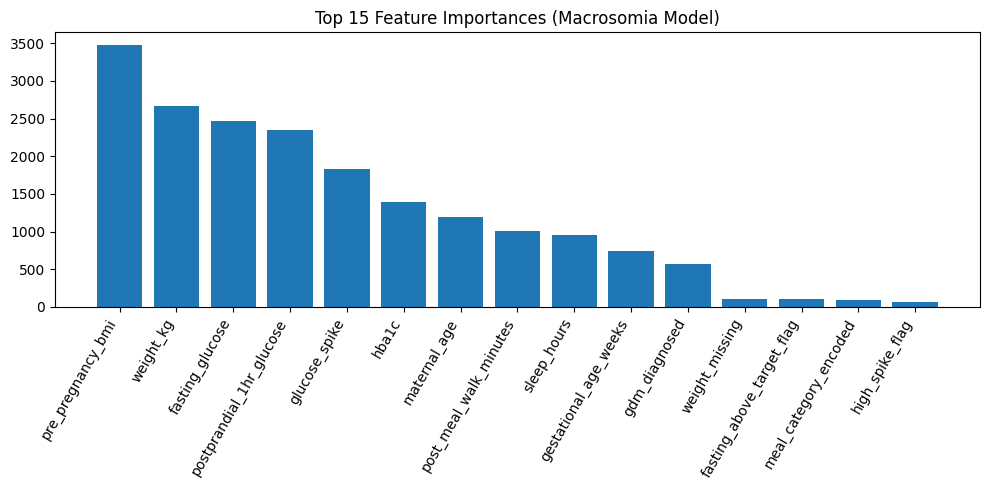

In [14]:
import matplotlib.pyplot as plt

imp = pd.DataFrame({
    "feature": X_cols,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

display(imp.head(15))

plt.figure(figsize=(10, 5))
plt.bar(imp["feature"].head(15), imp["importance"].head(15))
plt.xticks(rotation=60, ha="right")
plt.title("Top 15 Feature Importances (Macrosomia Model)")
plt.tight_layout()
plt.show()


## 12) Save Model Artifacts (Deployment + Retraining)

We save:
✅ model (.pkl)  
✅ features list (.json)  
✅ meal encoder (.pkl)  
✅ metrics (.json)  
✅ metadata (.json)  


In [15]:
MODEL_DIR = "models/macrosomia_v1"
os.makedirs(MODEL_DIR, exist_ok=True)

# Save model
joblib.dump(model, os.path.join(MODEL_DIR, "macrosomia_lgbm_model.pkl"))

# Save feature columns
with open(os.path.join(MODEL_DIR, "feature_columns.json"), "w") as f:
    json.dump(X_cols, f, indent=4)

# Save meal encoder
joblib.dump(le_meal, os.path.join(MODEL_DIR, "meal_category_encoder.pkl"))

# Save metrics
metrics = {
    "r2": float(r2),
    "mae": float(mae),
    "rmse": float(rmse)
}
with open(os.path.join(MODEL_DIR, "metrics.json"), "w") as f:
    json.dump(metrics, f, indent=4)

# Save metadata
metadata = {
    "model_name": "macrosomia_risk_score_lgbm",
    "version": "v1",
    "target": TARGET,
    "train_rows": int(len(X_train)),
    "test_rows": int(len(X_test)),
    "feature_count": int(len(X_cols)),
    "tier_thresholds": {"low_max": 0.399, "medium_max": 0.699, "high_min": 0.700},
    "notes": "Patient-wise split + engineered glucose features + diet encoding + early stopping."
}

with open(os.path.join(MODEL_DIR, "metadata.json"), "w") as f:
    json.dump(metadata, f, indent=4)

print("✅ Saved model + artifacts into:", MODEL_DIR)


✅ Saved model + artifacts into: models/macrosomia_v1


# ✅ Notebook Completed

### Outputs Saved
✅ `models/macrosomia_v1/macrosomia_lgbm_model.pkl`  
✅ `models/macrosomia_v1/feature_columns.json`  
✅ `models/macrosomia_v1/meal_category_encoder.pkl`  
✅ `models/macrosomia_v1/metrics.json`  
✅ `models/macrosomia_v1/metadata.json`

---

### Next Step
➡️ Deploy both models using FastAPI:
- `preeclampsia_lgbm_model.pkl`
- `macrosomia_lgbm_model.pkl`
